Path to dataset files: /kaggle/input/resume-dataset


In [1]:
import pandas as pd

df = pd.read_csv("Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [2]:
pip install gensim

^C
Note: you may need to restart the kernel to use updated packages.


Task A: Reproducible Setup and Data Checks

In [4]:
import torch
import numpy as np
import random
import pandas as pd
import transformers
import gensim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# A1. Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
print(f"Gensim Version: {gensim.__version__}")

# A2. Data Integrity Checks
# Assuming 'df' is already loaded from your previous cell
N = len(df)
unique_categories = df['Category'].nunique()
# Simple whitespace tokenization for length distribution
token_counts = df['Resume_str'].apply(lambda x: len(x.split()))

print(f"\nTotal Resumes (N): {N}")
print(f"Unique Categories: {unique_categories}")
print(f"Token Lengths - Min: {token_counts.min()}, Mean: {token_counts.mean():.2f}, Max: {token_counts.max()}")

print("\n--- Example Rows (Truncated) ---")
for i, row in df.head(3).iterrows():
    print(f"[{row['Category']}] {row['Resume_str'][:200]}...")

/usr/local/lib/python3.12/dist-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


PyTorch Version: 2.8.0+cu126
Transformers Version: 4.57.1
Gensim Version: 4.4.0

Total Resumes (N): 2484
Unique Categories: 24
Token Lengths - Min: 0, Mean: 811.33, Max: 5190

--- Example Rows (Truncated) ---
[HR]          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp...
[HR]          HR SPECIALIST, US HR OPERATIONS       Summary     Versatile  media professional with background in Communications, Marketing, Human Resources and Technology.         Experience     09/2015   ...
[HR]          HR DIRECTOR       Summary      Over 20 years experience in recruiting,   15 plus years in Human Resources Executive Management,   5 years of HRIS development and maintenance  4 years working ...


Task B: MiniLM Embedding + Retrieval

In [5]:
from transformers import AutoTokenizer, AutoModel

# B1. Model Loading
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval() # Set to inference mode

# B2. Mean Pooling function
def mean_pooling(model_output, attention_mask):
    # Extract token embeddings
    token_embeddings = model_output[0]
    # Expand mask to match embedding dimensions
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    # Sum embeddings while ignoring padding tokens
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    # L2 Normalization
    embeddings = sum_embeddings / sum_mask
    return torch.nn.functional.normalize(embeddings, p=2, dim=1)

# B3. Batch Encoder
def encode_miniLM(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)
            batch_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
            all_embeddings.append(batch_embeddings)

    return torch.cat(all_embeddings, dim=0)

# Generate Resume Embeddings
resume_texts = df['Resume_str'].tolist()
R_miniLM = encode_miniLM(resume_texts)

# B4. Ranking for HR JD
hr_query = "Human Resources Manager responsible for recruitment, employee relations, and benefits administration."
q_miniLM = encode_miniLM([hr_query])

# Scores s = qR^T
scores = torch.matmul(q_miniLM, R_miniLM.T).squeeze(0).numpy()
df['miniLM_score'] = scores

print("\n--- Top 5 MiniLM Results for HR JD ---")
top_5 = df.sort_values(by='miniLM_score', ascending=False).head(5)
for i, row in top_5.iterrows():
    print(f"Score: {row['miniLM_score']:.4f} | Cat: {row['Category']} | Text: {row['Resume_str'][:150]}...")

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

2026-02-11 15:29:57.389606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770823797.642052      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770823797.718285      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770823798.356477      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770823798.356535      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770823798.356539      17 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]


--- Top 5 MiniLM Results for HR JD ---
Score: 0.7282 | Cat: ADVOCATE | Text:          HUMAN RESOURCES MANAGER       Summary     To continue my professional Human Resource career in a position of leadership focused on creative p...
Score: 0.7091 | Cat: HR | Text:          HR MANAGER         Summary      Human Resources Manager with practical understanding of business needs. Areas of expertise include conflict m...
Score: 0.6695 | Cat: HR | Text:          HR MANAGER       Summary     Human Resources professional with the ability to work successfully with all levels of an organization, deliver e...
Score: 0.6640 | Cat: HR | Text:          HR GENERALIST           Summary     Human Resource Manager adding value by contributing to company growth and profitability. Trusted adviser ...
Score: 0.6635 | Cat: HR | Text:          HR MANAGER         Skill Highlights           HR SKILLS  HR Department Startup  Three New Organization Startups  Employment Law  FMLA/ADA/EEO...


Task C: Static Baselines (Word2Vec, GloVe)
C1 & C2: Word2Vec

In [6]:
from gensim.models import Word2Vec
import nltk
nltk.download('punkt')

# Simple tokenization
tokenized_resumes = [text.lower().split() for text in resume_texts]

# Train W2V
w2v_model = Word2Vec(sentences=tokenized_resumes, vector_size=100, window=5, min_count=5, sg=1, workers=4)

def get_w2v_doc_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    # Average and Normalize
    mean_vec = np.mean(vectors, axis=0)
    return mean_vec / (np.linalg.norm(mean_vec) + 1e-9)

R_w2v = np.array([get_w2v_doc_embedding(t, w2v_model) for t in tokenized_resumes])

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


C3 & C4: GloVe

In [7]:
# Download GloVe (This may take a minute)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

def load_glove(path):
    embeddings_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], "float32")
            embeddings_dict[word] = vector
    return embeddings_dict

glove_dict = load_glove("glove.6B.100d.txt")

def get_glove_doc_embedding(tokens, embeddings_dict):
    vectors = [embeddings_dict[word] for word in tokens if word in embeddings_dict]
    if not vectors:
        return np.zeros(100)
    mean_vec = np.mean(vectors, axis=0)
    return mean_vec / (np.linalg.norm(mean_vec) + 1e-9)

R_glove = np.array([get_glove_doc_embedding(t, glove_dict) for t in tokenized_resumes])

--2026-02-11 15:37:31--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-11 15:37:32--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-11 15:37:32--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.00MB/s    in 2m 42s  

2026-02-11 15:40:14 (5.07 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Task D: Evaluation (Acc@k and Gap)

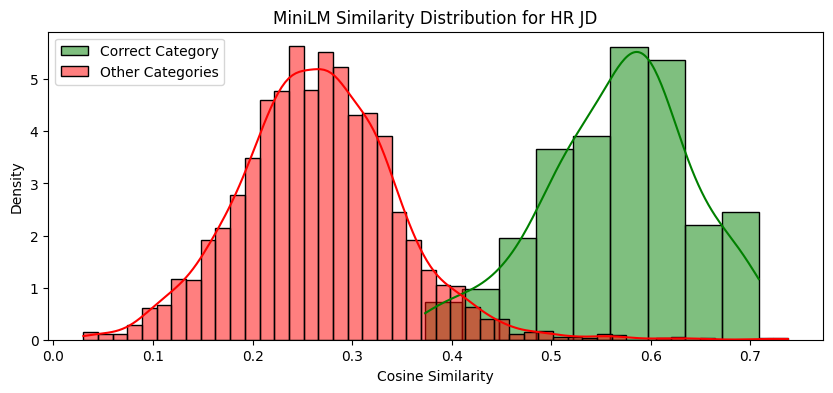

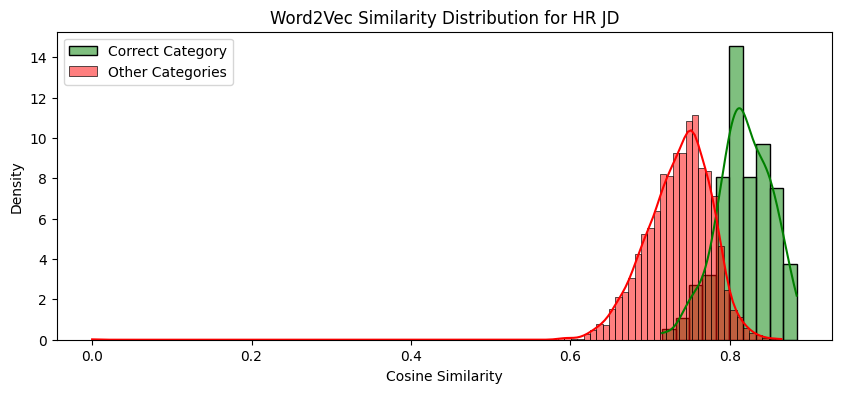

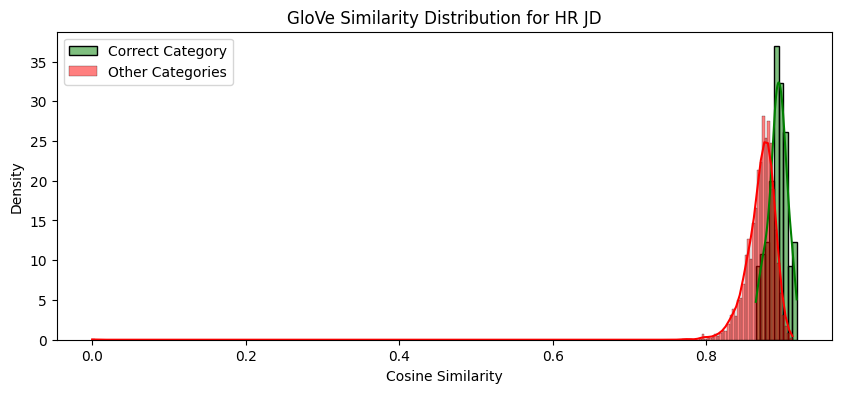


--- Evaluation Summary Table ---


,Category,Model,Acc@5,Acc@10,Gap
0,HR,MiniLM,0.6,0.8,0.300942
1,HR,Word2Vec,1.0,0.9,0.082537
2,HR,GloVe,1.0,0.8,0.022503
3,ADVOCATE,MiniLM,0.2,0.6,0.139250
4,ADVOCATE,Word2Vec,0.2,0.1,0.029964
5,ADVOCATE,GloVe,0.0,0.0,0.013311


In [8]:
# D1. Define JDs (Ensuring these match the categories in your CSV)
jds = {
    "HR": "Human Resources Manager: handle payroll, employee relations, recruitment, and benefits administration.",
    "ADVOCATE": "Legal Advocate: provide legal advice, represent clients in court proceedings, and draft legal documents."
}

def evaluate_retrieval(jd_text, target_cat, R_matrix, model_type):
    """
    Computes metrics for a specific JD and embedding model.
    model_type: 'minilm', 'word2vec', or 'glove'
    """
    # Normalize model_type to lowercase to avoid the error you saw
    model_type = model_type.lower()

    # Encode JD based on model type
    if model_type == "minilm":
        # Ensure we use the function from Task B
        q = encode_miniLM([jd_text]).numpy()
    elif "word2vec" in model_type or "w2v" in model_type:
        q = get_w2v_doc_embedding(jd_text.lower().split(), w2v_model).reshape(1, -1)
    elif "glove" in model_type:
        q = get_glove_doc_embedding(jd_text.lower().split(), glove_dict).reshape(1, -1)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Compute similarity: (N, d) @ (d, 1) -> (N, 1)
    sims = (R_matrix @ q.T).flatten()

    # Prepare results for ranking
    temp_df = pd.DataFrame({'sim': sims, 'cat': df['Category']})
    temp_df = temp_df.sort_values(by='sim', ascending=False).reset_index(drop=True)

    # D2. Acc@k (Category Proxy)
    # Using the indicator function: 1 if category matches, else 0
    acc5 = (temp_df.head(5)['cat'] == target_cat).mean()
    acc10 = (temp_df.head(10)['cat'] == target_cat).mean()

    # D3. Mean Similarity Gap
    mu_correct = temp_df[temp_df['cat'] == target_cat]['sim'].mean()
    mu_incorrect = temp_df[temp_df['cat'] != target_cat]['sim'].mean()
    gap = mu_correct - mu_incorrect

    return acc5, acc10, gap, mu_correct, mu_incorrect, temp_df

# Collect results
results = []
models_to_test = [
    ("MiniLM", R_miniLM.numpy()),
    ("Word2Vec", R_w2v),
    ("GloVe", R_glove)
]

for cat_name, jd_content in jds.items():
    for m_name, m_mat in models_to_test:
        # Call the corrected function
        a5, a10, gap, m_corr, m_incorr, plot_df = evaluate_retrieval(jd_content, cat_name, m_mat, m_name)

        results.append({
            "Category": cat_name,
            "Model": m_name,
            "Acc@5": a5,
            "Acc@10": a10,
            "Gap": gap,
            "Mu_Correct": m_corr,
            "Mu_Incorrect": m_incorr
        })

        # D4. Visualization (Only for HR to save space, but creates plots for all models)
        if cat_name == "HR":
            plt.figure(figsize=(10, 4))
            sns.histplot(plot_df[plot_df['cat'] == cat_name]['sim'], color="green", label="Correct Category", kde=True, stat="density")
            sns.histplot(plot_df[plot_df['cat'] != cat_name]['sim'], color="red", label="Other Categories", kde=True, stat="density")
            plt.title(f"{m_name} Similarity Distribution for {cat_name} JD")
            plt.xlabel("Cosine Similarity")
            plt.legend()
            plt.show()

# Display the summary table
perf_df = pd.DataFrame(results)
print("\n--- Evaluation Summary Table ---")
display(perf_df[["Category", "Model", "Acc@5", "Acc@10", "Gap"]])

Task E: Threshold Retrieval Study

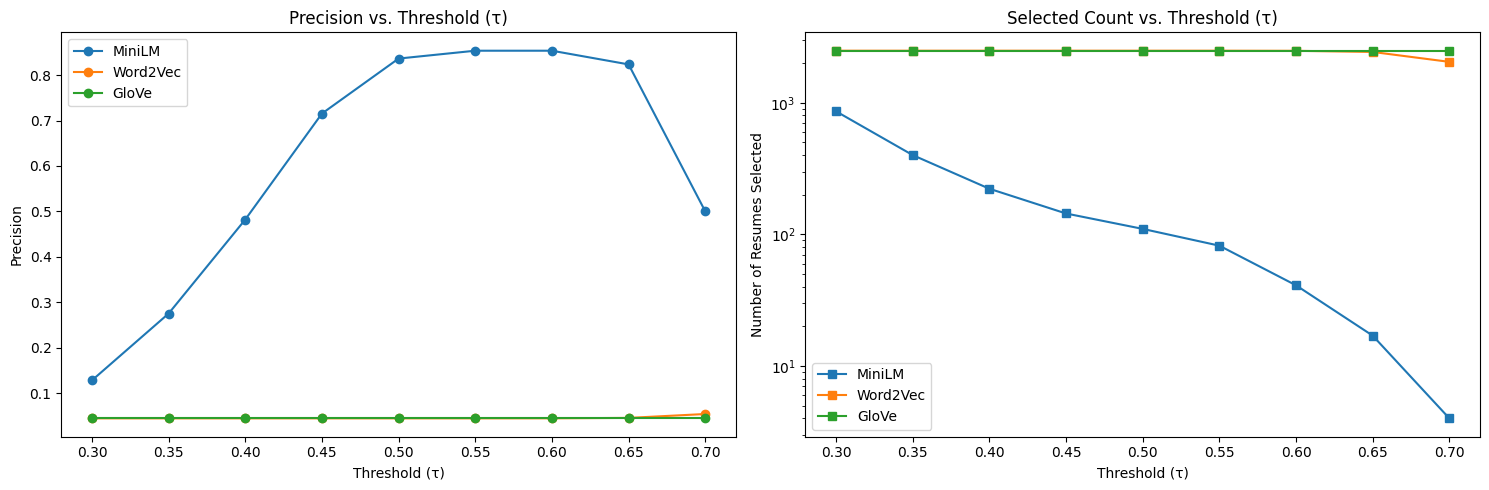


--- Explanation ---
As the threshold τ increases, the model becomes more 'selective'. This usually leads to higher Precision (fewer false positives) but a much lower 'Selected Count', as only the most semantically similar resumes pass the filter.


In [9]:
# E1. Threshold Sweep for HR
hr_jd = jds["HR"]
thresholds = np.arange(0.30, 0.75, 0.05)

def threshold_sweep(jd_text, target_cat, R_matrix, model_type):
    # Normalize model type for safety
    m_type = model_type.lower()

    # 1. Encode the query JD
    if m_type == "minilm":
        q = encode_miniLM([jd_text]).numpy()
    elif "word2vec" in m_type or "w2v" in m_type:
        q = get_w2v_doc_embedding(jd_text.lower().split(), w2v_model).reshape(1, -1)
    elif "glove" in m_type:
        q = get_glove_doc_embedding(jd_text.lower().split(), glove_dict).reshape(1, -1)

    # 2. Compute similarity scores s = qR^T
    sims = (R_matrix @ q.T).flatten()

    sweep_res = []
    for t in thresholds:
        # 3. Apply threshold tau
        selected_mask = sims > t
        count = np.sum(selected_mask)

        if count > 0:
            # Precision = (Selected & Correct) / Total Selected
            correct_count = np.sum(df.loc[selected_mask, 'Category'] == target_cat)
            prec = correct_count / count
        else:
            prec = 0

        sweep_res.append({"t": t, "count": count, "precision": prec})

    return pd.DataFrame(sweep_res)

# E2. Plotting
models_to_sweep = [
    ("MiniLM", R_miniLM.numpy()),
    ("Word2Vec", R_w2v),
    ("GloVe", R_glove)
]

plt.figure(figsize=(15, 5))

for i, (m_name, m_mat) in enumerate(models_to_sweep):
    sweep_df = threshold_sweep(hr_jd, "HR", m_mat, m_name)

    # Precision Plot
    plt.subplot(1, 2, 1)
    plt.plot(sweep_df['t'], sweep_df['precision'], marker='o', label=m_name)
    plt.title("Precision vs. Threshold (τ)")
    plt.xlabel("Threshold (τ)")
    plt.ylabel("Precision")
    plt.legend()

    # Selected Count Plot
    plt.subplot(1, 2, 2)
    plt.plot(sweep_df['t'], sweep_df['count'], marker='s', label=m_name)
    plt.title("Selected Count vs. Threshold (τ)")
    plt.xlabel("Threshold (τ)")
    plt.ylabel("Number of Resumes Selected")
    plt.yscale('log') # Use log scale because count drops fast
    plt.legend()

plt.tight_layout()
plt.show()

print("\n--- Explanation ---")
print("As the threshold τ increases, the model becomes more 'selective'. This usually leads to higher Precision "
      "(fewer false positives) but a much lower 'Selected Count', as only the most semantically similar resumes pass the filter.")